## **Stock Price Numerical Analyzer (NumPy)**

In [ ]:
#Step 1: Load Dataset Using NumPy
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt(
    "/content/AAPL.csv",
    delimiter=",",
    skip_header=1,
    usecols=(1, 2, 3, 4, 5)
)

open_p = data[:, 0]
high_p = data[:, 1]
low_p  = data[:, 2]
close_p = data[:, 3]
volume = data[:, 4]


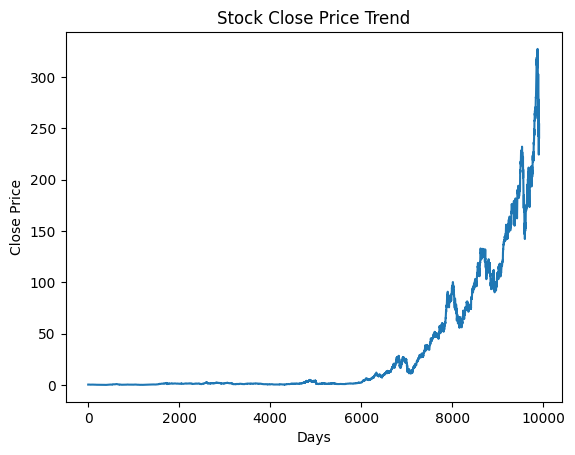

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(close_p)
plt.title("Stock Close Price Trend")
plt.xlabel("Days")
plt.ylabel("Close Price")
plt.show()


In [ ]:
#Step 2: Calculate Daily Returns
print(np.diff(close_p))

print(close_p[:-1])

daily_returns = np.diff(close_p) / close_p[:-1]

print(daily_returns)

[-2.67857313e-02 -3.57142687e-02  1.11607015e-02 ...  7.06999207e+00
 -5.20004272e-01 -1.33799896e+01]
[  0.51339287   0.48660713   0.45089287 ... 247.74000549 254.80999756
 254.28999329]
[-0.05217395 -0.07339446  0.02475245 ...  0.02853795 -0.00204075
 -0.05261705]


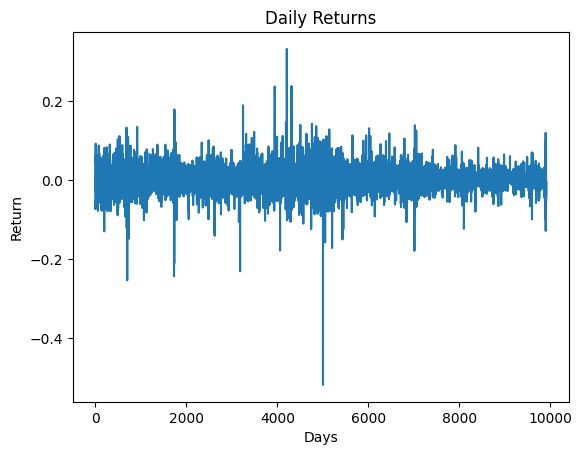

In [ ]:
plt.figure()
plt.plot(daily_returns)
plt.title("Daily Returns")
plt.xlabel("Days")
plt.ylabel("Return")
plt.show()


In [ ]:
#Step 3: Average Return & Volatility
average_return = np.mean(daily_returns)
volatility = np.std(daily_returns)

print(f'Average Return : {average_return}')
print(f'Volatility : {volatility}')

Average Return : 0.001041334236172605
Volatility : 0.028736293446199324


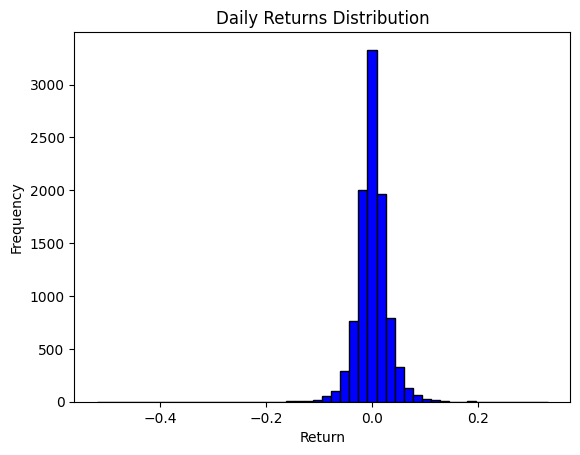

In [ ]:
plt.figure()
plt.hist(daily_returns, bins=50, color='blue', edgecolor='Black')
plt.title("Daily Returns Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()


In [ ]:
#Step 4: Best & Worst Trading Day
best_day=np.argmax(daily_returns)
worst_day=np.argmin(daily_returns)
print("Best Day Return:", daily_returns[best_day])
print("Worst Day Return:", daily_returns[worst_day])

Best Day Return: 0.33227848502386653
Worst Day Return: -0.5186915800387978


In [ ]:
#Step 5: Moving Average
def moving_average(data, window):
    return np.convolve(data, np.ones(window)/window, mode='valid')

ma_5 = moving_average(close_p, 5)
ma_20 = moving_average(close_p, 20)
print(ma_5)
print(ma_20)


[  0.47767857   0.47589285   0.484375   ... 250.67800293 252.16000061
 251.23800049]
[  0.55435268   0.55591518   0.55892857 ... 261.03350143 259.28200073
 256.1905014 ]


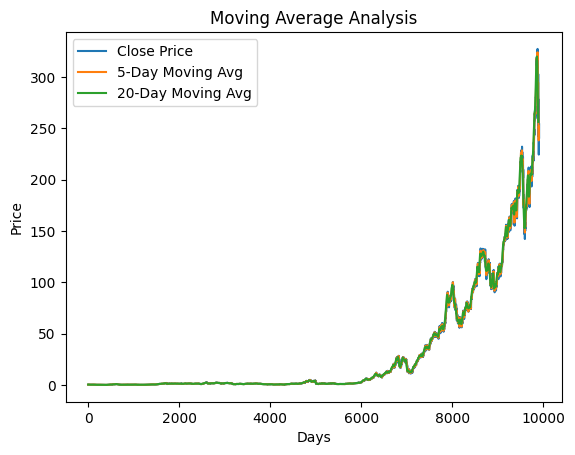

In [ ]:
plt.figure()
plt.plot(close_p, label="Close Price")
plt.plot(ma_5, label="5-Day Moving Avg")
plt.plot(ma_20, label="20-Day Moving Avg")

plt.title("Moving Average Analysis")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()


In [ ]:
#Step 6: High-Risk Days Detection
risk_threshold = 0.03   # 3% change
high_risk_days = np.where(np.abs(daily_returns) > risk_threshold)

print("High Risk Days Index:", high_risk_days)


High Risk Days Index: (array([   0,    1,    4, ..., 9903, 9904, 9907]),)


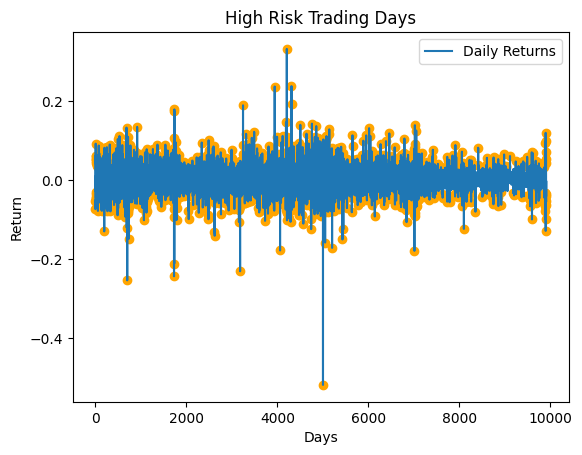

In [ ]:
plt.figure()
plt.plot(daily_returns, label="Daily Returns")
plt.scatter(high_risk_days, daily_returns[high_risk_days], color='orange')

plt.title("High Risk Trading Days")
plt.xlabel("Days")
plt.ylabel("Return")
plt.legend()
plt.show()


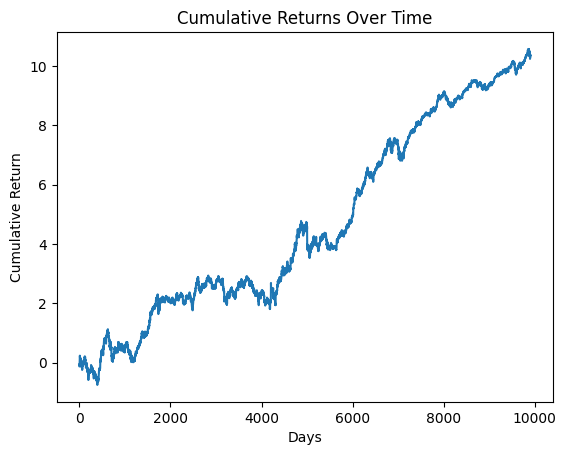

In [ ]:
cumulative_returns = np.cumsum(daily_returns)

plt.figure()
plt.plot(cumulative_returns)
plt.title("Cumulative Returns Over Time")
plt.xlabel("Days")
plt.ylabel("Cumulative Return")
plt.show()
